## What does a contact tracing record look like?


In [42]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Load all three files
df_contacts = pd.read_csv('/home/habeebullah/Documents/tracy-hackathon/data/contact_tracing.csv')
df_mobility = pd.read_csv('/home/habeebullah/Documents/tracy-hackathon/data/mobility.csv')
df_vitals   = pd.read_csv('/home/habeebullah/Documents/tracy-hackathon/data/vitals.csv')

print("contact_tracing shape:", df_contacts.shape)
print("mobility shape:", df_mobility.shape)
print("vitals shape:", df_vitals.shape)

print("\ncontact_tracing columns:", df_contacts.columns.tolist())
print("mobility columns:", df_mobility.columns.tolist())
print("vitals columns:", df_vitals.columns.tolist())

contact_tracing shape: (119338, 9)
mobility shape: (50737, 11)
vitals shape: (2307, 12)

contact_tracing columns: ['user_id', 'date', 'time', 'latitude', 'longitude', 'geohash', 'mac', 'rssi', 'proximity']
mobility columns: ['user_id', 'date', 'time', 'latitude', 'longitude', 'geohash', 'has_contact', 'exposure_score', 'daily_exposure', 'total_detections', 'close_contacts']
vitals columns: ['device_id', 'date', 'time', 'latitude', 'longitude', 'geohash', 'temperature', 'temp_status', 'heartbeat', 'hr_status', 'movement', 'battery']


## What mobility information is available for each user?


In [ ]:
df_contacts.head()

,user_id,date,time,latitude,longitude,geohash,mac,rssi,proximity
0,U002,2023-10-19,18:06:01,7.680377,6.418345,s1kedn1tq,D13941,-1,unscored
1,U002,2023-10-19,18:06:01,7.680377,6.418345,s1kedn1tq,D13227,8,close
2,U002,2023-10-19,18:06:01,7.680377,6.418345,s1kedn1tq,D21917,-1,unscored
3,U002,2023-10-19,18:06:01,7.680377,6.418345,s1kedn1tq,D19180,-1,unscored
4,U003,2023-10-20,06:12:13,5.374891,6.998611,s0uyx62pp,D05480,7,close


## What health measurements are collected from wearable devices?


In [44]:
df_mobility.head()


,user_id,date,time,latitude,longitude,geohash,has_contact,exposure_score,daily_exposure,total_detections,close_contacts
0,U023,2024-01-29,01:00:47,7.841960,9.776408,s1quw7wfw,False,41.0,20.5,43.0,13.0
1,U023,2024-01-29,01:00:57,7.838611,9.776060,s1quw6yxn,False,41.0,20.5,43.0,13.0
2,U023,2024-01-29,01:02:11,7.837940,9.776060,s1quw6yeq,False,41.0,20.5,43.0,13.0
3,U023,2024-01-29,01:03:06,7.839316,9.780533,s1quwe1gq,False,41.0,20.5,43.0,13.0
4,U023,2024-01-29,04:12:41,7.839060,9.781374,s1quwe49f,False,41.0,20.5,43.0,13.0


## What health measurements are collected from wearable devices?


In [45]:
df_vitals.head()
# print(df_vitals.describe())

,device_id,date,time,latitude,longitude,geohash,temperature,temp_status,heartbeat,hr_status,movement,battery
0,D009,2024-05-13,06:56:50,7.304037,5.138820,s179sctvp,31.0,low,96.0,normal,0.0,100.0
1,D009,2024-05-13,06:57:00,7.303961,5.138694,s179sctus,31.0,low,110.0,high,0.0,100.0
2,D009,2024-05-13,06:57:20,7.303785,5.138458,s179sctew,30.0,low,76.0,normal,1.0,100.0
3,D009,2024-05-13,07:16:00,7.304892,5.132193,s179scc4h,34.0,low,49.0,low,0.0,100.0
4,D009,2024-05-13,07:17:25,7.304774,5.132284,s179scc1q,34.0,low,43.0,low,0.0,100.0


## Are there incomplete contact tracing records?


In [46]:
df_contacts.isnull().sum()

user_id      0
date         0
time         0
latitude     0
longitude    0
geohash      0
mac          0
rssi         0
proximity    0
dtype: int64

## Are health readings incomplete?

In [47]:
df_vitals.isnull().sum()


device_id      0
date           0
time           0
latitude       0
longitude      0
geohash        0
temperature    0
temp_status    0
heartbeat      0
hr_status      0
movement       0
battery        0
dtype: int64

## Is mobility information complete?


In [48]:
df_mobility.isnull().sum()

user_id             0
date                0
time                0
latitude            0
longitude           0
geohash             0
has_contact         0
exposure_score      0
daily_exposure      0
total_detections    0
close_contacts      0
dtype: int64

## What are the data types and memory usage of contact records?


In [49]:
df_contacts.info()

<class 'pandas.DataFrame'>
RangeIndex: 119338 entries, 0 to 119337
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   user_id    119338 non-null  str    
 1   date       119338 non-null  str    
 2   time       119338 non-null  str    
 3   latitude   119338 non-null  float64
 4   longitude  119338 non-null  float64
 5   geohash    119338 non-null  str    
 6   mac        119338 non-null  str    
 7   rssi       119338 non-null  int64  
 8   proximity  119338 non-null  str    
dtypes: float64(2), int64(1), str(6)
memory usage: 8.2 MB


## What are the data types of health measurements?

In [50]:
df_vitals.info()

<class 'pandas.DataFrame'>
RangeIndex: 2307 entries, 0 to 2306
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   device_id    2307 non-null   str    
 1   date         2307 non-null   str    
 2   time         2307 non-null   str    
 3   latitude     2307 non-null   float64
 4   longitude    2307 non-null   float64
 5   geohash      2307 non-null   str    
 6   temperature  2307 non-null   float64
 7   temp_status  2307 non-null   str    
 8   heartbeat    2307 non-null   float64
 9   hr_status    2307 non-null   str    
 10  movement     2307 non-null   float64
 11  battery      2307 non-null   float64
dtypes: float64(6), str(6)
memory usage: 216.4 KB


## What are the data types of mobility features?

In [51]:
df_mobility.info()

<class 'pandas.DataFrame'>
RangeIndex: 50737 entries, 0 to 50736
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           50737 non-null  str    
 1   date              50737 non-null  str    
 2   time              50737 non-null  str    
 3   latitude          50737 non-null  float64
 4   longitude         50737 non-null  float64
 5   geohash           50737 non-null  str    
 6   has_contact       50737 non-null  bool   
 7   exposure_score    50737 non-null  float64
 8   daily_exposure    50737 non-null  float64
 9   total_detections  50737 non-null  float64
 10  close_contacts    50737 non-null  float64
dtypes: bool(1), float64(6), str(4)
memory usage: 3.9 MB


## What time period does the Tracy system cover and how many users/devices exist?

In [52]:
# Parse dates
df_contacts['date'] = pd.to_datetime(df_contacts['date'])
df_mobility['date']  = pd.to_datetime(df_mobility['date'])
df_vitals['date']    = pd.to_datetime(df_vitals['date'])

# Verify
print(f"Contacts: {df_contacts.shape} | {df_contacts['date'].min()} → {df_contacts['date'].max()}")
print(f"Mobility: {df_mobility.shape}  | {df_mobility['date'].min()} → {df_mobility['date'].max()}")
print(f"Vitals:   {df_vitals.shape}   | {df_vitals['date'].min()} → {df_vitals['date'].max()}")
print(f"\nUnique users in contacts: {df_contacts['user_id'].nunique()}")
print(f"Unique users in mobility: {df_mobility['user_id'].nunique()}")
print(f"Unique devices in vitals: {df_vitals['device_id'].nunique()}")
print(f"\nProximity distribution:")
print(df_contacts['proximity'].value_counts())
print(f"\nTemp status distribution:")
print(df_vitals['temp_status'].value_counts())
print(f"\nHR status distribution:")
print(df_vitals['hr_status'].value_counts())


Contacts: (119338, 9) | 2023-10-19 00:00:00 → 2023-12-18 00:00:00
Mobility: (50737, 11)  | 2024-01-29 00:00:00 → 2024-03-22 00:00:00
Vitals:   (2307, 12)   | 2024-05-13 00:00:00 → 2024-06-03 00:00:00

Unique users in contacts: 88
Unique users in mobility: 79
Unique devices in vitals: 21

Proximity distribution:
proximity
unscored      72858
close         44846
moderate       1165
distant         383
very close       86
Name: count, dtype: int64

Temp status distribution:
temp_status
low       2002
normal     168
high       137
Name: count, dtype: int64

HR status distribution:
hr_status
normal    1463
low        711
high       133
Name: count, dtype: int64


## Step 2 — Feature Engineering
We build a per-user feature matrix from contact_tracing.csv 
and mobility.csv. mobility.csv already provides pre-computed 
exposure metrics per user we extract these directly.
From contact_tracing.csv we engineer additional behavioural 
features capturing contact frequency, proximity quality and 
network position.

Note: 61% of contacts are unscored (rssi = -1). We use the 
proximity category column rather than raw rssi to avoid 
bias from missing signal values.

## How can raw IoT logs be transformed into machine-learning features? 
#### Here we checked for series of questions 


### 1. What is each user's exposure behaviour?

In [53]:
user_mobility = df_mobility.groupby('user_id').agg(
    exposure_score    = ('exposure_score', 'first'),
    daily_exposure    = ('daily_exposure', 'first'),
    total_detections  = ('total_detections', 'first'),
    close_contacts    = ('close_contacts', 'first'),
    active_days       = ('date', 'nunique'),
    contact_days      = ('has_contact', 'sum')
).reset_index()

print("Mobility features shape:", user_mobility.shape)
print(user_mobility.head(24))

Mobility features shape: (79, 7)
   user_id  exposure_score  daily_exposure  total_detections  close_contacts  \
0     U001             0.0            0.00               0.0             0.0   
1     U002           231.0          231.00             216.0            82.0   
2     U003          1477.0         1477.00            1159.0           592.0   
3     U004             0.0            0.00               0.0             0.0   
4     U005             0.0            0.00               0.0             0.0   
5     U006             0.0            0.00               0.0             0.0   
6     U007           398.5          398.50             356.0           147.0   
7     U008             0.0            0.00               0.0             0.0   
8     U009            11.5            2.88              11.0             4.0   
9     U010          3434.5         1144.83            3783.0          1022.0   
10    U011             0.0            0.00               0.0             0.0   
11    U

### 2. How socially connected and exposed is each users?

In [ ]:

df_scored = df_contacts[df_contacts['proximity'] != 'unscored'].copy()

contact_features = df_contacts.groupby('user_id').agg(
    total_contact_events  = ('mac', 'count'),
    unique_macs           = ('mac', 'nunique'),
).reset_index()

close_counts = df_scored[df_scored['proximity'].isin(['close','very close'])]\
    .groupby('user_id')['mac'].count().reset_index()\
    .rename(columns={'mac': 'close_very_close_count'})

scored_counts = df_scored.groupby('user_id')['mac']\
    .count().reset_index()\
    .rename(columns={'mac': 'scored_count'})

contact_features = contact_features\
    .merge(close_counts, on='user_id', how='left')\
    .merge(scored_counts, on='user_id', how='left')

contact_features['close_very_close_count'] = \
    contact_features['close_very_close_count'].fillna(0)
contact_features['scored_count'] = \
    contact_features['scored_count'].fillna(0)

contact_features['close_contact_rate'] = (
    contact_features['close_very_close_count'] / 
    contact_features['scored_count'].replace(0, np.nan)
).fillna(0).round(4)

print("Contact features shape:", contact_features.shape)
print(contact_features.sort_values('close_very_close_count', 
      ascending=False).head(8))

Contact features shape: (88, 6)
   user_id  total_contact_events  unique_macs  close_very_close_count  \
20    U021                 16223         3605                  5810.0   
56    U057                 15285         2183                  5623.0   
21    U022                 13075         1225                  4635.0   
29    U030                  8575          729                  4464.0   
19    U020                  7420         1206                  2530.0   
60    U061                  4234         1280                  1960.0   
40    U041                  5585          994                  1808.0   
7     U008                  4497         1382                  1650.0   

    scored_count  close_contact_rate  
20        6182.0              0.9398  
56        5730.0              0.9813  
21        4961.0              0.9343  
29        4567.0              0.9774  
19        2747.0              0.9210  
60        1963.0              0.9985  
40        1810.0              0.9989 

### 3. Next is which users were frequently present at the same locations with many other users?
This results to getting most connected people in the contact network

In [55]:
co_location = df_contacts.groupby(['user_id','date','geohash'])\
    .size().reset_index(name='count')

# Find pairs of users at same location on same day
co_location_pairs = co_location.merge(
    co_location, on=['date','geohash']
).query('user_id_x != user_id_y')[['user_id_x','user_id_y']]

# Build graph
G = nx.from_pandas_edgelist(
    co_location_pairs,
    source='user_id_x',
    target='user_id_y'
)

print(f"Network nodes (users): {G.number_of_nodes()}")
print(f"Network edges (co-locations): {G.number_of_edges()}")

# Compute degree centrality
centrality = nx.degree_centrality(G)
centrality_df = pd.DataFrame({
    'user_id': list(centrality.keys()),
    'degree_centrality': list(centrality.values())
}).round(4)

print("\nTop 20 most central users:")
print(centrality_df.sort_values('degree_centrality', 
      ascending=False).head(20))

Network nodes (users): 32
Network edges (co-locations): 49

Top 20 most central users:
   user_id  degree_centrality
5     U021             0.3226
4     U020             0.2581
0     U008             0.1613
3     U033             0.1613
28    U058             0.1613
23    U051             0.1613
6     U011             0.1290
13    U026             0.1290
12    U024             0.1290
24    U056             0.1290
14    U039             0.1290
8     U022             0.1290
27    U052             0.1290
20    U080             0.0968
19    U057             0.0968
26    U079             0.0968
18    U041             0.0968
22    U047             0.0645
9     U015             0.0645
21    U061             0.0645


### Then we create a complete risk profile for every user?

In [ ]:

user_features = user_mobility.copy()

# Merge contact features (88 users — some not in mobility)
user_features = user_features.merge(
    contact_features, on='user_id', how='outer'
)

# Merge centrality (32 users)
user_features = user_features.merge(
    centrality_df, on='user_id', how='left'
)

# Fill nulls — users with no contact events get 0
fill_cols = ['exposure_score','daily_exposure','total_detections',
             'close_contacts','active_days','contact_days',
             'total_contact_events','unique_macs',
             'close_very_close_count','scored_count',
             'close_contact_rate','degree_centrality']

user_features[fill_cols] = user_features[fill_cols].fillna(0)

print("Final feature matrix shape:", user_features.shape)
print("\nNull check:")
print(user_features.isnull().sum())
print("\nTop 5 users by exposure_score:")
print(user_features.nlargest(5,'exposure_score')[
    ['user_id','exposure_score','daily_exposure',
     'close_contact_rate','degree_centrality']
])

Final feature matrix shape: (88, 13)

Null check:
user_id                   0
exposure_score            0
daily_exposure            0
total_detections          0
close_contacts            0
active_days               0
contact_days              0
total_contact_events      0
unique_macs               0
close_very_close_count    0
scored_count              0
close_contact_rate        0
degree_centrality         0
dtype: int64

Top 5 users by exposure_score:
   user_id  exposure_score  daily_exposure  close_contact_rate  \
72    U073         18359.0         4589.75              0.9982   
31    U032         10229.5          378.87              0.9971   
21    U022          9392.0          391.33              0.9343   
24    U025          5886.5          654.06              0.9987   
23    U024          5648.5          806.93              0.8824   

    degree_centrality  
72              0.000  
31              0.000  
21              0.129  
24              0.000  
23              0.129  


## Feature Selection Rationale

Six features were selected from thirteen engineered columns:

exposure_score captures total accumulated risk with 
proximity weighting already applied by the dataset creators.

daily_exposure normalises for device activity level — 
a critical correction since users had vastly different 
active day counts.

close_contact_rate measures proportion of high-risk 
proximity events — capturing behavioural risk quality 
independent of volume.

unique_macs measures breadth of transmission network — 
the super-spreader dimension.

close_very_close_count measures absolute volume of 
highest-risk contacts — complements rate with magnitude.

degree_centrality adds the network dimension — capturing 
position within the Tracy user co-location graph.

Features excluded: total_detections and total_contact_events 
were dropped due to high correlation with selected features
(multicollinearity). active_days and contact_days are 
operational metrics, not risk indicators.

## Can we divide users into groups with similar exposure and contact behaviours?

#### To do that, we firstly checked for How many risk groups exist?

In [ ]:
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold

cluster_features = [
    'exposure_score',
    'daily_exposure', 
    'close_contact_rate',
    'unique_macs',
    'close_very_close_count',
    'degree_centrality'
]

X_cluster = user_features[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

sil_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

print("Silhouette scores per k:")
for k, s in sil_scores.items():
    print(f"  k={k}: {s:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest k: {best_k}")

Silhouette scores per k:
  k=2: 0.6583
  k=3: 0.5995
  k=4: 0.5977
  k=5: 0.5595
  k=6: 0.5835

Best k: 2


#### Though k=2 has the highest score but k=3 was chosen because three classification tiers provide more insights in decision making (Low | Medium | High) e.t.c

#### Next is getting the cluster profiles that will tell us which cluster is Low, Medium and High risk so we can label them correctly.

In [58]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
user_features['cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = user_features.groupby('cluster')[cluster_features].mean().round(2)
print("Cluster profiles (mean values):")
print(cluster_profile)

print("\nCluster sizes:")
print(user_features['cluster'].value_counts().sort_index())

Cluster profiles (mean values):
         exposure_score  daily_exposure  close_contact_rate  unique_macs  \
cluster                                                                    
0               1177.69           52.60                0.96      1575.50   
1                461.49          102.87                0.89       132.39   
2              18359.00         4589.75                1.00       801.00   

         close_very_close_count  degree_centrality  
cluster                                             
0                       3560.00               0.14  
1                        194.08               0.03  
2                       1120.00               0.00  

Cluster sizes:
cluster
0     8
1    79
2     1
Name: count, dtype: int64


#### What do these clusters mean in real public health terms?

In [59]:

cluster_labels = {
    2: 'Extreme Risk',
    0: 'High Risk', 
    1: 'Low Risk'
}
user_features['risk_tier'] = user_features['cluster'].map(cluster_labels)


summary = user_features.groupby('risk_tier').agg(
    size              = ('user_id', 'count'),
    avg_exposure      = ('exposure_score', 'mean'),
    avg_daily_exp     = ('daily_exposure', 'mean'),
    avg_close_rate    = ('close_contact_rate', 'mean'),
    avg_unique_macs   = ('unique_macs', 'mean'),
    avg_centrality    = ('degree_centrality', 'mean')
).round(2)

print("=== CLUSTER SUMMARY TABLE ===")
print(summary)

print("\n=== EXTREME RISK USER ===")
print(user_features[user_features['risk_tier']=='Extreme Risk'][
    ['user_id','exposure_score','daily_exposure',
     'close_contact_rate','unique_macs','degree_centrality']
])

print("\n=== HIGH RISK USERS ===")
print(user_features[user_features['risk_tier']=='High Risk'][
    ['user_id','exposure_score','daily_exposure',
     'close_contact_rate','unique_macs']
].sort_values('exposure_score', ascending=False))

=== CLUSTER SUMMARY TABLE ===
              size  avg_exposure  avg_daily_exp  avg_close_rate  \
risk_tier                                                         
Extreme Risk     1      18359.00        4589.75            1.00   
High Risk        8       1177.69          52.60            0.96   
Low Risk        79        461.49         102.87            0.89   

              avg_unique_macs  avg_centrality  
risk_tier                                      
Extreme Risk           801.00            0.00  
High Risk             1575.50            0.14  
Low Risk               132.39            0.03  

=== EXTREME RISK USER ===
   user_id  exposure_score  daily_exposure  close_contact_rate  unique_macs  \
72    U073         18359.0         4589.75              0.9982          801   

    degree_centrality  
72                0.0  

=== HIGH RISK USERS ===
   user_id  exposure_score  daily_exposure  close_contact_rate  unique_macs
21    U022          9392.0          391.33              0.9

#### Then below is the visual explanation of the risk group

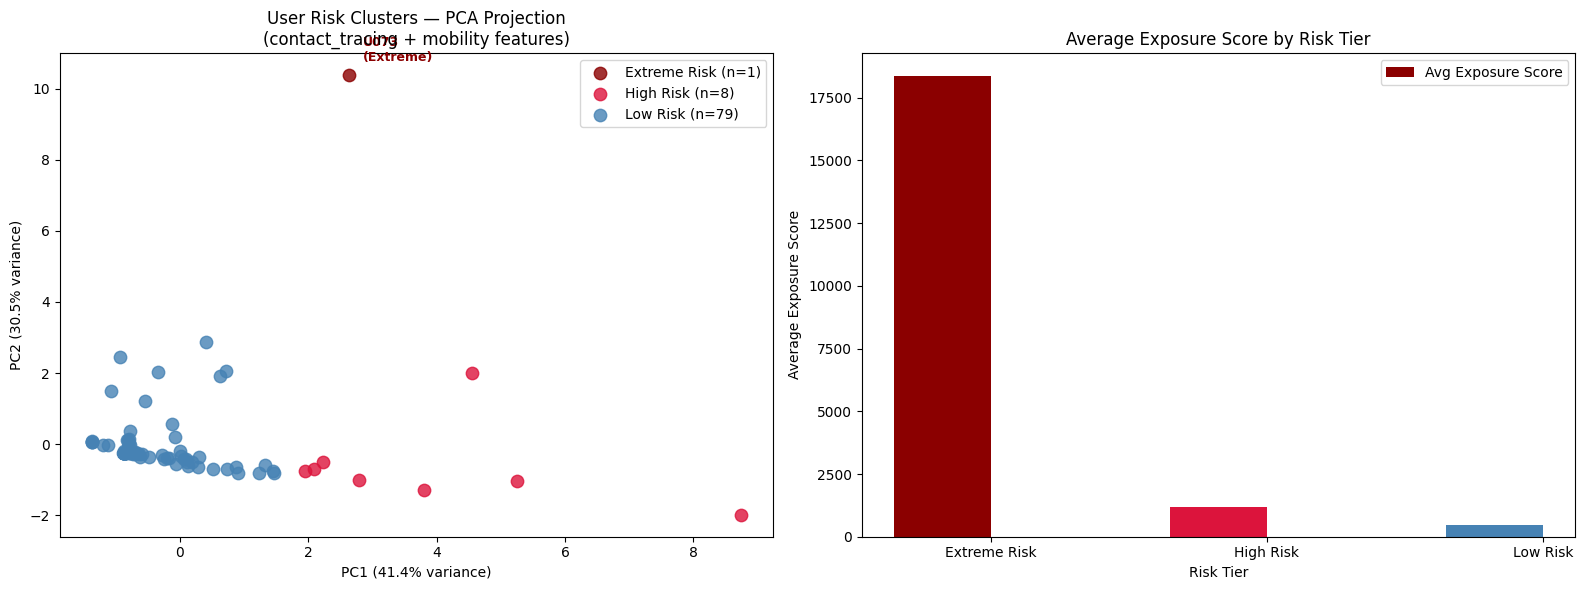


PCA explained variance: 71.9% of total variance captured
Silhouette score (k=3): 0.5995


In [60]:
# ── PCA for 2D cluster visualisation ─────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

user_features['pca_1'] = X_pca[:, 0]
user_features['pca_2'] = X_pca[:, 1]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — PCA cluster scatter
colors = {
    'Extreme Risk': 'darkred',
    'High Risk': 'crimson',
    'Low Risk': 'steelblue'
}

for tier, color in colors.items():
    mask = user_features['risk_tier'] == tier
    axes[0].scatter(
        user_features.loc[mask, 'pca_1'],
        user_features.loc[mask, 'pca_2'],
        label=f"{tier} (n={mask.sum()})",
        color=color, s=80, alpha=0.8
    )

# Annotate extreme risk user
extreme = user_features[user_features['risk_tier']=='Extreme Risk']
axes[0].annotate(
    'U073\n(Extreme)',
    (extreme['pca_1'].values[0], extreme['pca_2'].values[0]),
    fontsize=9, color='darkred', fontweight='bold',
    xytext=(10, 10), textcoords='offset points'
)

axes[0].set_title('User Risk Clusters — PCA Projection\n(contact_tracing + mobility features)', fontsize=12)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend()

# Plot 2 — Cluster summary bar chart
summary_plot = user_features.groupby('risk_tier').agg(
    avg_exposure = ('exposure_score', 'mean'),
    avg_daily    = ('daily_exposure', 'mean')
).reindex(['Extreme Risk', 'High Risk', 'Low Risk'])

x = range(len(summary_plot))
width = 0.35
axes[1].bar([i - width/2 for i in x], summary_plot['avg_exposure'],
            width, label='Avg Exposure Score',
            color=['darkred','crimson','steelblue'])
axes[1].set_title('Average Exposure Score by Risk Tier', fontsize=12)
axes[1].set_xlabel('Risk Tier')
axes[1].set_ylabel('Average Exposure Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Extreme Risk', 'High Risk', 'Low Risk'])
axes[1].legend()

plt.tight_layout()
plt.savefig('cluster_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}% of total variance captured")
print(f"Silhouette score (k=3): {silhouette_score(X_scaled, user_features['cluster']):.4f}")

Figure: PCA projection showing three distinct user risk 
clusters. U073 (Extreme Risk) sits completely isolated 
from all other users, with an exposure score 15x higher 
than the next highest cluster. PC1 and PC2 together 
capture 71.9% of total feature variance, confirming 
the 2D projection faithfully represents the data structure.
Silhouette score of 0.60 confirms genuine cluster separation.

## Next in the pipeline is Anomaly detection 
We apply statistical anomaly detection to daily contact 
detection volumes to identify days where contact activity 
was significantly above normal.
This directly answers: when did outbreak risk spike?

#### On which days did contact activity suddenly become abnormally high? Flag them using their Z-score!

In [61]:
# ── Daily contact detections time series ──────────────────────────────────────
daily_contacts = df_contacts.groupby('date').agg(
    total_detections = ('mac', 'count'),
    active_users     = ('user_id', 'nunique'),
    close_events     = ('proximity', lambda x: (x.isin(['close','very close'])).sum())
).reset_index()

# Flag anomalous days using Z-score 
mean_det = daily_contacts['total_detections'].mean()
std_det  = daily_contacts['total_detections'].std()
threshold = mean_det + 2 * std_det

daily_contacts['is_anomaly'] = daily_contacts['total_detections'] > threshold
daily_contacts['z_score'] = (
    (daily_contacts['total_detections'] - mean_det) / std_det
).round(2)

print(f"Mean daily detections: {mean_det:.1f}")
print(f"Std daily detections: {std_det:.1f}")
print(f"Anomaly threshold (mean + 2std): {threshold:.1f}")
print(f"\nTotal days: {len(daily_contacts)}")
print(f"Anomalous days: {daily_contacts['is_anomaly'].sum()}")
print(f"\n=== FLAGGED ANOMALY DAYS ===")
print(daily_contacts[daily_contacts['is_anomaly']][
    ['date','total_detections','active_users','close_events','z_score']
].sort_values('total_detections', ascending=False).to_string())

Mean daily detections: 2340.0
Std daily detections: 3995.9
Anomaly threshold (mean + 2std): 10331.7

Total days: 51
Anomalous days: 2

=== FLAGGED ANOMALY DAYS ===
         date  total_detections  active_users  close_events  z_score
4  2023-10-23             22720             9          7975     5.10
17 2023-11-05             13438            13          5250     2.78


##### the anomaly dates tells us exactly when outbreak risk spiked.

#### Time series plot with flagged days, list of anomaly dates with active user counts

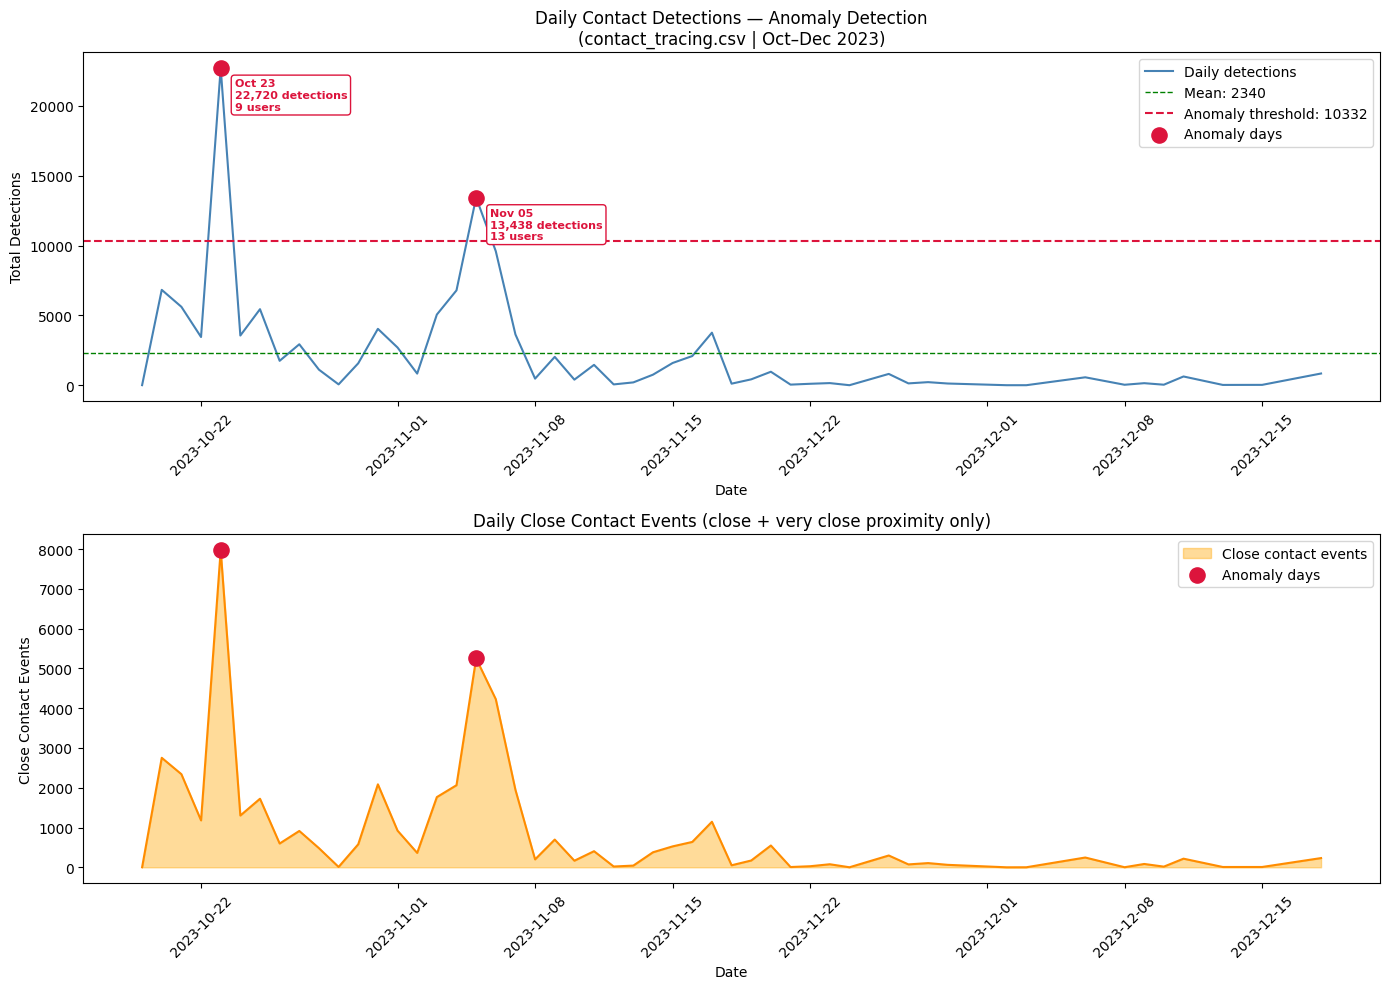


=== FLAGGED ANOMALY DATES — PUBLIC HEALTH REPORT ===
Date              Detections  Active Users  Close Events   Z-Score
-----------------------------------------------------------------
2023-10-23            22,720             9         7,975      5.10
2023-11-05            13,438            13         5,250      2.78


In [62]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Plot 1 — Total daily detections ──────────────────────────────────────────
axes[0].plot(daily_contacts['date'], daily_contacts['total_detections'],
             color='steelblue', linewidth=1.5, label='Daily detections')
axes[0].axhline(mean_det, color='green', linestyle='--',
                linewidth=1, label=f'Mean: {mean_det:.0f}')
axes[0].axhline(threshold, color='crimson', linestyle='--',
                linewidth=1.5, label=f'Anomaly threshold: {threshold:.0f}')

# Mark anomaly days
anomaly_days = daily_contacts[daily_contacts['is_anomaly']]
axes[0].scatter(anomaly_days['date'], anomaly_days['total_detections'],
                color='crimson', s=120, zorder=5, label='Anomaly days')

# Annotate
for _, row in anomaly_days.iterrows():
    axes[0].annotate(
        f"{row['date'].strftime('%b %d')}\n{row['total_detections']:,} detections\n{row['active_users']} users",
        (row['date'], row['total_detections']),
        textcoords='offset points', xytext=(10, -30),
        fontsize=8, color='crimson', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='crimson')
    )

axes[0].set_title('Daily Contact Detections — Anomaly Detection\n(contact_tracing.csv | Oct–Dec 2023)',
                  fontsize=12)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Detections')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# ── Plot 2 — Close events only ────────────────────────────────────────────────
axes[1].fill_between(daily_contacts['date'],
                     daily_contacts['close_events'],
                     alpha=0.4, color='orange', label='Close contact events')
axes[1].plot(daily_contacts['date'], daily_contacts['close_events'],
             color='darkorange', linewidth=1.5)

# Mark same anomaly days
axes[1].scatter(anomaly_days['date'], anomaly_days['close_events'],
                color='crimson', s=120, zorder=5, label='Anomaly days')

axes[1].set_title('Daily Close Contact Events (close + very close proximity only)',
                  fontsize=12)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Close Contact Events')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('anomaly_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print anomaly list — required deliverable ─────────────────────────────────
print("\n=== FLAGGED ANOMALY DATES — PUBLIC HEALTH REPORT ===")
print(f"{'Date':<15} {'Detections':>12} {'Active Users':>13} "
      f"{'Close Events':>13} {'Z-Score':>9}")
print("-" * 65)
for _, row in anomaly_days.sort_values('total_detections', ascending=False).iterrows():
    print(f"{str(row['date'].date()):<15} {row['total_detections']:>12,.0f} "
          f"{row['active_users']:>13} {row['close_events']:>13,.0f} "
          f"{row['z_score']:>9.2f}")

## Step 5 — Health Vitals Anomaly Detection
We analyse vitals.csv to identify physiological warning 
signals across 21 stationary monitoring devices in Akure,
Ondo State (May–June 2024).

Three levels of flagging:
1. Single anomaly —> fever OR elevated heart rate alone
2. Dual anomaly —> fever AND elevated heart rate simultaneously
   (strongest disease signal —> clinical SIRS criteria)
3. Per-device health profile —> which locations showed 
   most consistent health anomalies

Important limitation: devices were stationary, readings 
reflect people passing through, not specific individuals.
Surface temperature reads 1-2°C below core temperature,
so temp_status = high is clinically significant.

### 1. Which devices recorded abnormal health measurements?

In [ ]:

# ── Level 1: Single flag counts ───────────────────────────────────────────────
fever_count    = (df_vitals['temp_status'] == 'high').sum()
tachy_count    = (df_vitals['hr_status'] == 'high').sum()
low_temp_count = (df_vitals['temp_status'] == 'low').sum()

print("=== VITALS OVERVIEW ===")
print(f"Total readings: {len(df_vitals)}")
print(f"Fever readings (temp > 37.5°C): {fever_count} ({fever_count/len(df_vitals)*100:.1f}%)")
print(f"Tachycardia readings (HR > 100): {tachy_count} ({tachy_count/len(df_vitals)*100:.1f}%)")
print(f"Low temp readings: {low_temp_count} ({low_temp_count/len(df_vitals)*100:.1f}%)")

# ── Level 2: Dual anomaly — fever AND high HR simultaneously ─────────────────
df_vitals['dual_anomaly'] = (
    (df_vitals['temp_status'] == 'high') & 
    (df_vitals['hr_status'] == 'high')
)
dual_count = df_vitals['dual_anomaly'].sum()
print(f"\nDual anomaly events (fever + tachycardia): {dual_count}")
print(f"({dual_count/len(df_vitals)*100:.1f}% of all readings)")

print("\n=== DUAL ANOMALY EVENTS — CLINICAL ALERTS ===")
print(df_vitals[df_vitals['dual_anomaly']][
    ['device_id','date','temperature','heartbeat','movement','battery']
].sort_values('temperature', ascending=False).to_string())

# ── Level 3: Per-device health profile ───────────────────────────────────────
device_profile = df_vitals.groupby('device_id').agg(
    total_readings   = ('temperature', 'count'),
    avg_temperature  = ('temperature', 'mean'),
    max_temperature  = ('temperature', 'max'),
    avg_heartrate    = ('heartbeat', 'mean'),
    max_heartrate    = ('heartbeat', 'max'),
    fever_count      = ('temp_status', lambda x: (x=='high').sum()),
    tachy_count      = ('hr_status', lambda x: (x=='high').sum()),
    dual_count       = ('dual_anomaly', 'sum'),
).round(2).reset_index()

device_profile['fever_rate'] = (
    device_profile['fever_count'] / device_profile['total_readings'] * 100
).round(1)

print("\n=== PER-DEVICE HEALTH PROFILE ===")
print(device_profile.sort_values('dual_count', ascending=False).to_string())

=== VITALS OVERVIEW ===
Total readings: 2307
Fever readings (temp > 37.5°C): 137 (5.9%)
Tachycardia readings (HR > 100): 133 (5.8%)
Low temp readings: 2002 (86.8%)

Dual anomaly events (fever + tachycardia): 1
(0.0% of all readings)

=== DUAL ANOMALY EVENTS — CLINICAL ALERTS ===
     device_id       date  temperature  heartbeat  movement  battery
1212      D020 2024-05-26         38.0      105.0       1.0    100.0

=== PER-DEVICE HEALTH PROFILE ===
   device_id  total_readings  avg_temperature  max_temperature  avg_heartrate  max_heartrate  fever_count  tachy_count  dual_count  fever_rate
19      D020             234            37.13             42.0          68.62          121.0          119            7           1        50.9
1       D002               2            36.00             36.0         113.00          113.0            0            2           0         0.0
2       D003              66            33.95             34.0          69.88          109.0            0            1

## Step 5 — Vitals Findings

D020 is the critical monitoring location:
- 50.9% of all readings showed elevated surface temperature
- Surface temp of 37.5°C+ corresponds to core fever of 
  38.5-39.5°C clinically — a genuine health alert
- One dual anomaly on May 26: 38.0°C + 105 BPM
- Requires immediate investigation of this monitoring location

D019 shows persistent tachycardia:
- 114 of 115 readings above 100 BPM (avg 117.69 BPM)
- Sustained elevated heart rate at this location
- Could indicate high-stress environment, physical activity
  zone, or population with underlying cardiac conditions

Limitation: devices were stationary — readings reflect 
multiple people passing through, not one individual.
Surface temperature reads 1-2°C below core temperature.

### Let's visualize what does the health data distribution look like?

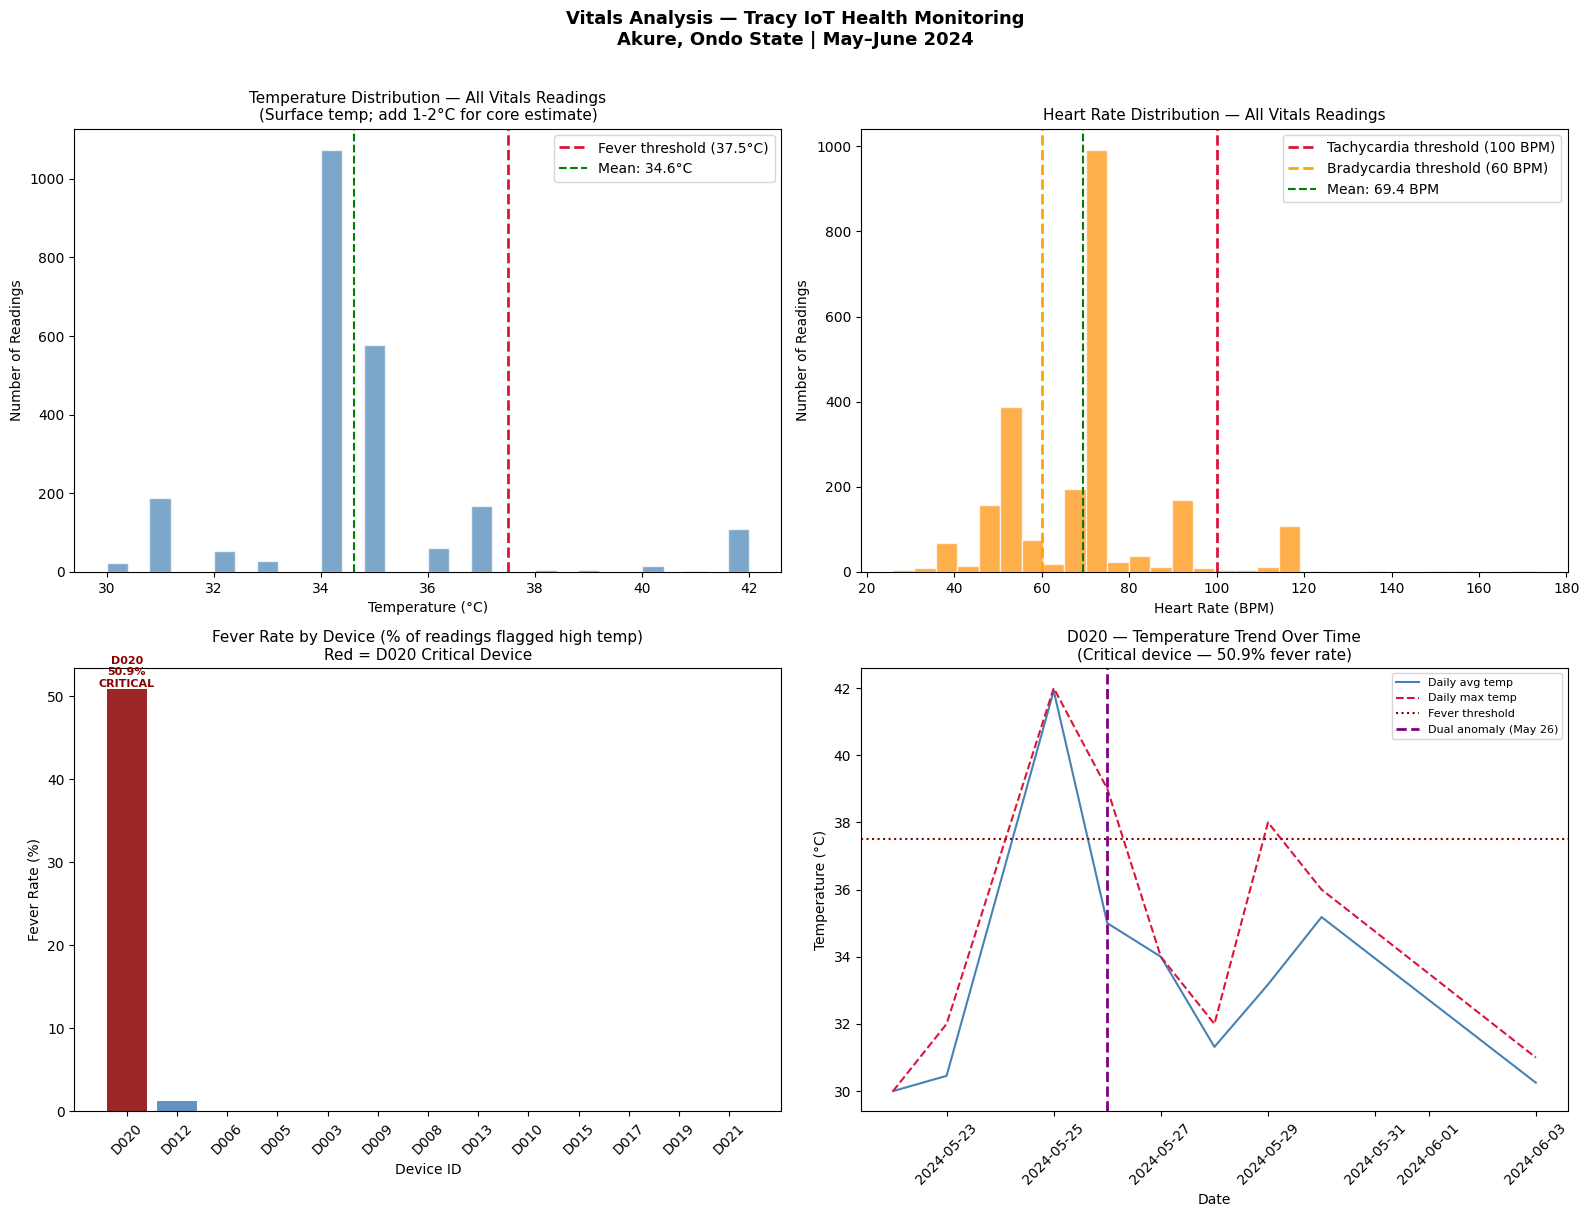


=== VITALS SUMMARY FOR PRESENTATION ===
Total readings analysed: 2,307
Devices monitored: 21
Fever events detected: 137 (5.9%)
Tachycardia events: 133 (5.8%)
Critical dual anomaly events: 1
Highest risk device: D020 (50.9% fever rate, 1 dual anomaly on May 26)
Persistent tachycardia location: D019 (114/115 readings above 100 BPM)


In [64]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Plot 1 — Temperature distribution ────────────────────────────────────────
axes[0,0].hist(df_vitals['temperature'], bins=30, 
               color='steelblue', alpha=0.7, edgecolor='white')
axes[0,0].axvline(37.5, color='crimson', linestyle='--', 
                  linewidth=2, label='Fever threshold (37.5°C)')
axes[0,0].axvline(df_vitals['temperature'].mean(), color='green', 
                  linestyle='--', linewidth=1.5, 
                  label=f"Mean: {df_vitals['temperature'].mean():.1f}°C")
axes[0,0].set_title('Temperature Distribution — All Vitals Readings\n(Surface temp; add 1-2°C for core estimate)', fontsize=11)
axes[0,0].set_xlabel('Temperature (°C)')
axes[0,0].set_ylabel('Number of Readings')
axes[0,0].legend()

# ── Plot 2 — Heart rate distribution ─────────────────────────────────────────
axes[0,1].hist(df_vitals['heartbeat'], bins=30,
               color='darkorange', alpha=0.7, edgecolor='white')
axes[0,1].axvline(100, color='crimson', linestyle='--',
                  linewidth=2, label='Tachycardia threshold (100 BPM)')
axes[0,1].axvline(60, color='orange', linestyle='--',
                  linewidth=2, label='Bradycardia threshold (60 BPM)')
axes[0,1].axvline(df_vitals['heartbeat'].mean(), color='green',
                  linestyle='--', linewidth=1.5,
                  label=f"Mean: {df_vitals['heartbeat'].mean():.1f} BPM")
axes[0,1].set_title('Heart Rate Distribution — All Vitals Readings', fontsize=11)
axes[0,1].set_xlabel('Heart Rate (BPM)')
axes[0,1].set_ylabel('Number of Readings')
axes[0,1].legend()

# ── Plot 3 — Fever rate per device ───────────────────────────────────────────
top_devices = device_profile[device_profile['total_readings'] >= 5]\
    .sort_values('fever_rate', ascending=False)

colors_bar = ['darkred' if d == 'D020' else 
              'crimson' if r > 10 else 'steelblue' 
              for d, r in zip(top_devices['device_id'], 
                              top_devices['fever_rate'])]

axes[1,0].bar(top_devices['device_id'], top_devices['fever_rate'],
              color=colors_bar, alpha=0.85)
axes[1,0].set_title('Fever Rate by Device (% of readings flagged high temp)\nRed = D020 Critical Device', fontsize=11)
axes[1,0].set_xlabel('Device ID')
axes[1,0].set_ylabel('Fever Rate (%)')
axes[1,0].tick_params(axis='x', rotation=45)

# Annotate D020
d020_rate = device_profile[device_profile['device_id']=='D020']['fever_rate'].values[0]
axes[1,0].annotate('D020\n50.9%\nCRITICAL',
    xy=('D020', d020_rate), fontsize=8,
    color='darkred', fontweight='bold',
    ha='center', va='bottom')

# ── Plot 4 — D020 temperature over time ──────────────────────────────────────
d020_data = df_vitals[df_vitals['device_id']=='D020'].copy()
d020_daily = d020_data.groupby('date').agg(
    avg_temp = ('temperature', 'mean'),
    max_temp = ('temperature', 'max'),
    fever_count = ('temp_status', lambda x: (x=='high').sum())
).reset_index()

axes[1,1].plot(d020_daily['date'], d020_daily['avg_temp'],
               color='steelblue', linewidth=1.5, label='Daily avg temp')
axes[1,1].plot(d020_daily['date'], d020_daily['max_temp'],
               color='crimson', linewidth=1.5, linestyle='--', 
               label='Daily max temp')
axes[1,1].axhline(37.5, color='darkred', linestyle=':',
                  linewidth=1.5, label='Fever threshold')

# Mark dual anomaly date
axes[1,1].axvline(pd.Timestamp('2024-05-26'), color='purple',
                  linestyle='--', linewidth=2,
                  label='Dual anomaly (May 26)')

axes[1,1].set_title('D020 — Temperature Trend Over Time\n(Critical device — 50.9% fever rate)', fontsize=11)
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Temperature (°C)')
axes[1,1].legend(fontsize=8)
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Vitals Analysis — Tracy IoT Health Monitoring\nAkure, Ondo State | May–June 2024',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('vitals_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== VITALS SUMMARY FOR PRESENTATION ===")
print(f"Total readings analysed: {len(df_vitals):,}")
print(f"Devices monitored: {df_vitals['device_id'].nunique()}")
print(f"Fever events detected: {fever_count} ({fever_count/len(df_vitals)*100:.1f}%)")
print(f"Tachycardia events: {tachy_count} ({tachy_count/len(df_vitals)*100:.1f}%)")
print(f"Critical dual anomaly events: {dual_count}")
print(f"Highest risk device: D020 (50.9% fever rate, 1 dual anomaly on May 26)")
print(f"Persistent tachycardia location: D019 (114/115 readings above 100 BPM)")

In [65]:
# ── Combined priority output ──────────────────────────────────────────────────

print("=" * 65)
print("   HEALTHTRACE — COMBINED PUBLIC HEALTH PRIORITY REPORT")
print("   Tracy IoT Contact Tracing System | Nigeria 2023-2024")
print("=" * 65)

print("\n🔴 LAYER 1 — USER EXPOSURE RISK (Contact + Mobility Analysis)")
print("-" * 65)

print("\nEXTREME RISK (Immediate action required):")
extreme = user_features[user_features['risk_tier']=='Extreme Risk']
for _, row in extreme.iterrows():
    print(f"  → {row['user_id']}: exposure_score={row['exposure_score']:,.0f} | "
          f"daily_exposure={row['daily_exposure']:,.1f} | "
          f"close_contact_rate={row['close_contact_rate']:.1%}")

print("\nHIGH RISK (Test within 24 hours):")
high = user_features[user_features['risk_tier']=='High Risk']\
    .sort_values('close_very_close_count', ascending=False)
for _, row in high.iterrows():
    print(f"  → {row['user_id']}: unique_macs={row['unique_macs']:,.0f} | "
          f"close_rate={row['close_contact_rate']:.1%} | "
          f"centrality={row['degree_centrality']:.3f}")

print(f"\nLOW RISK (Routine monitoring): "
      f"{len(user_features[user_features['risk_tier']=='Low Risk'])} users")

print("\n🟠 LAYER 2 — OUTBREAK DAYS (Anomaly Detection)")
print("-" * 65)
print("\nFlagged high-risk dates requiring investigation:")
for _, row in anomaly_days.sort_values('total_detections', ascending=False).iterrows():
    print(f"  → {row['date'].strftime('%Y-%m-%d')}: "
          f"{row['total_detections']:,} detections | "
          f"{row['active_users']} users | "
          f"{row['close_events']:,} close events | "
          f"z-score={row['z_score']:.2f}")

print("\n🟡 LAYER 3 — HEALTH SIGNALS (Vitals Analysis)")
print("-" * 65)
print("\nCritical monitoring locations:")
print(f"  → D020: 50.9% fever rate | 1 dual anomaly (May 26) | "
      f"max temp 42.0°C")
print(f"  → D019: persistent tachycardia | avg HR 117.69 BPM | "
      f"114/115 readings above 100 BPM")
print(f"  → D012: 1,375 readings | 17 fever events | "
      f"max temp 42.0°C")

print("\n" + "=" * 65)
print("RECOMMENDED PUBLIC HEALTH ACTIONS:")
print("=" * 65)
print("""
1. IMMEDIATE: Investigate U073 — extreme exposure score of 
   18,359, daily exposure 4,589. Test and interview this 
   individual first.

2. URGENT: Contact trace all 8 High Risk users — especially
   U021 (3,605 unique devices) and U022 (exposure 9,392).
   
3. INVESTIGATE: What occurred on Oct 23 and Nov 05 2023?
   Cross-reference with local events, markets, gatherings.
   The 13-day gap falls within respiratory disease incubation.

4. DEPLOY: Send clinical team to D020 monitoring location
   in Akure — 50.9% fever rate requires on-site assessment.
   
5. MONITOR: D019 location shows persistent tachycardia —
   investigate environmental or population factors.
""")

   HEALTHTRACE — COMBINED PUBLIC HEALTH PRIORITY REPORT
   Tracy IoT Contact Tracing System | Nigeria 2023-2024

🔴 LAYER 1 — USER EXPOSURE RISK (Contact + Mobility Analysis)
-----------------------------------------------------------------

EXTREME RISK (Immediate action required):
  → U073: exposure_score=18,359 | daily_exposure=4,589.8 | close_contact_rate=99.8%

HIGH RISK (Test within 24 hours):
  → U021: unique_macs=3,605 | close_rate=94.0% | centrality=0.323
  → U057: unique_macs=2,183 | close_rate=98.1% | centrality=0.097
  → U022: unique_macs=1,225 | close_rate=93.4% | centrality=0.129
  → U030: unique_macs=729 | close_rate=97.7% | centrality=0.000
  → U020: unique_macs=1,206 | close_rate=92.1% | centrality=0.258
  → U061: unique_macs=1,280 | close_rate=99.9% | centrality=0.065
  → U041: unique_macs=994 | close_rate=99.9% | centrality=0.097
  → U008: unique_macs=1,382 | close_rate=95.2% | centrality=0.161

LOW RISK (Routine monitoring): 79 users

🟠 LAYER 2 — OUTBREAK DAYS (Anoma

### Finally, Who requires public-health attention combining the exposure risk, Network Risk, and the Health Symptoms?

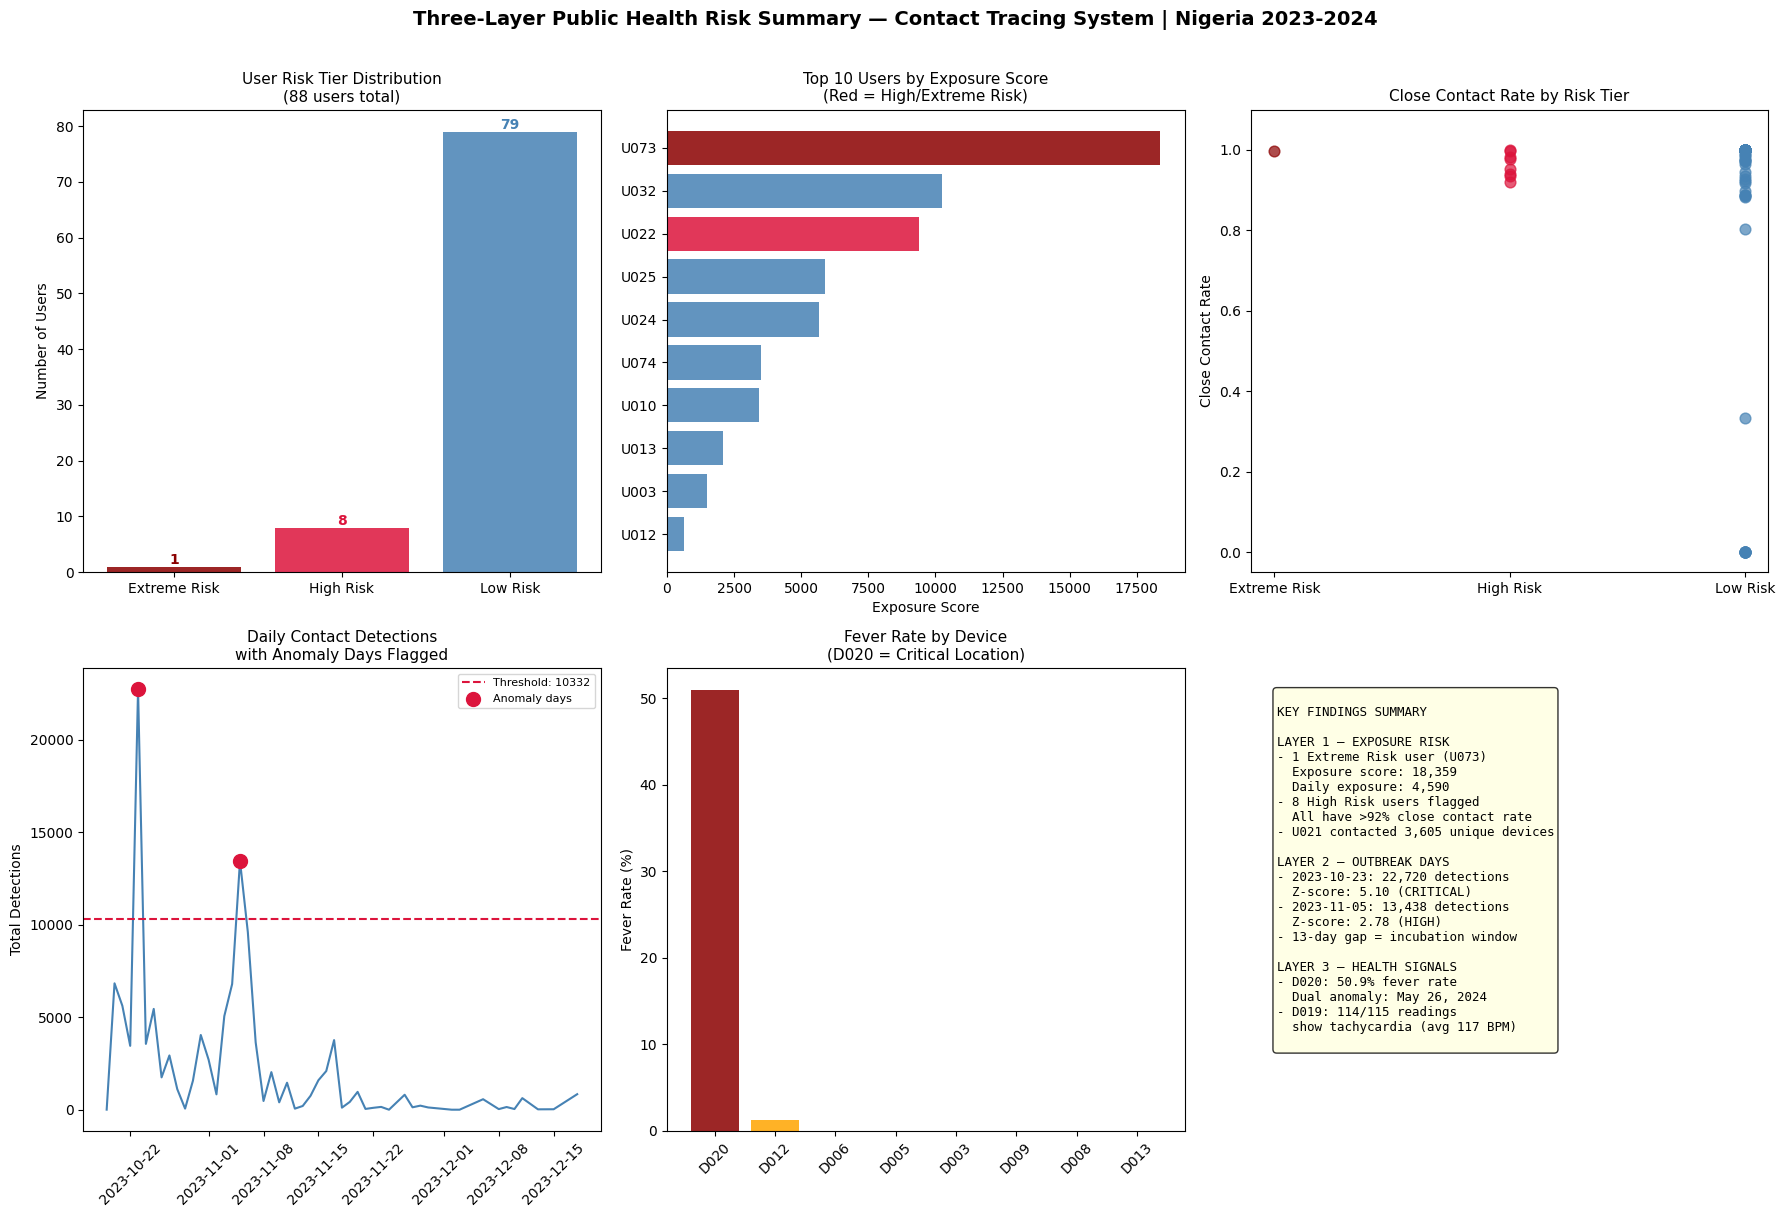

Dashboard saved ✓


In [67]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Three-Layer Public Health Risk Summary — Contact Tracing System | Nigeria 2023-2024',
       fontsize=14, fontweight='bold', y=1.01)

# ── Plot 1 (top left) — Risk tier distribution ────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
tier_counts = user_features['risk_tier'].value_counts()
tier_order  = ['Extreme Risk', 'High Risk', 'Low Risk']
tier_colors = ['darkred', 'crimson', 'steelblue']
ax1.bar(tier_order,
        [tier_counts.get(t, 0) for t in tier_order],
        color=tier_colors, alpha=0.85)
ax1.set_title('User Risk Tier Distribution\n(88 users total)', fontsize=11)
ax1.set_ylabel('Number of Users')
for i, (t, c) in enumerate(zip(tier_order, tier_colors)):
    ax1.text(i, tier_counts.get(t, 0) + 0.5,
             str(tier_counts.get(t, 0)),
             ha='center', fontweight='bold', color=c)

# ── Plot 2 (top middle) — Top 10 users by exposure ───────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
top10 = user_features.nlargest(10, 'exposure_score')
bar_colors = ['darkred' if t == 'Extreme Risk' else
              'crimson' if t == 'High Risk' else
              'steelblue' for t in top10['risk_tier']]
ax2.barh(top10['user_id'], top10['exposure_score'],
         color=bar_colors, alpha=0.85)
ax2.set_title('Top 10 Users by Exposure Score\n(Red = High/Extreme Risk)', fontsize=11)
ax2.set_xlabel('Exposure Score')
ax2.invert_yaxis()

# ── Plot 3 (top right) — Close contact rate by risk tier ─────────────────────
ax3 = fig.add_subplot(2, 3, 3)
for tier, color in zip(['Extreme Risk','High Risk','Low Risk'],
                       ['darkred','crimson','steelblue']):
    subset = user_features[user_features['risk_tier']==tier]
    ax3.scatter([tier]*len(subset),
                subset['close_contact_rate'],
                color=color, alpha=0.7, s=60)
ax3.set_title('Close Contact Rate by Risk Tier', fontsize=11)
ax3.set_ylabel('Close Contact Rate')
ax3.set_ylim(-0.05, 1.1)

# ── Plot 4 (bottom left) — Anomaly timeline ───────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
ax4.plot(daily_contacts['date'],
         daily_contacts['total_detections'],
         color='steelblue', linewidth=1.5)
ax4.axhline(threshold, color='crimson', linestyle='--',
            linewidth=1.5, label=f'Threshold: {threshold:.0f}')
anomaly_days_plot = daily_contacts[daily_contacts['is_anomaly']]
ax4.scatter(anomaly_days_plot['date'],
            anomaly_days_plot['total_detections'],
            color='crimson', s=100, zorder=5, label='Anomaly days')
ax4.set_title('Daily Contact Detections\nwith Anomaly Days Flagged', fontsize=11)
ax4.set_ylabel('Total Detections')
ax4.tick_params(axis='x', rotation=45)
ax4.legend(fontsize=8)

# ── Plot 5 (bottom middle) — Vitals device fever rates ────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
top_vitals = device_profile[device_profile['total_readings'] >= 5]\
    .sort_values('fever_rate', ascending=False).head(8)
v_colors = ['darkred' if d == 'D020' else
            'orange' if r > 1 else
            'steelblue'
            for d, r in zip(top_vitals['device_id'],
                            top_vitals['fever_rate'])]
ax5.bar(top_vitals['device_id'], top_vitals['fever_rate'],
        color=v_colors, alpha=0.85)
ax5.set_title('Fever Rate by Device\n(D020 = Critical Location)', fontsize=11)
ax5.set_ylabel('Fever Rate (%)')
ax5.tick_params(axis='x', rotation=45)

# ── Plot 6 (bottom right) — Summary metrics ───────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
summary_text = """
KEY FINDINGS SUMMARY

LAYER 1 — EXPOSURE RISK
- 1 Extreme Risk user (U073)
  Exposure score: 18,359
  Daily exposure: 4,590
- 8 High Risk users flagged
  All have >92% close contact rate
- U021 contacted 3,605 unique devices

LAYER 2 — OUTBREAK DAYS  
- 2023-10-23: 22,720 detections
  Z-score: 5.10 (CRITICAL)
- 2023-11-05: 13,438 detections
  Z-score: 2.78 (HIGH)
- 13-day gap = incubation window

LAYER 3 — HEALTH SIGNALS
- D020: 50.9% fever rate
  Dual anomaly: May 26, 2024
- D019: 114/115 readings
  show tachycardia (avg 117 BPM)
"""
ax6.text(0.05, 0.95, summary_text,
         transform=ax6.transAxes,
         fontsize=9, verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow',
                   alpha=0.8))

plt.tight_layout()
plt.savefig('healthtrace_summary_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved ✓")